#**Assignment 2** — Your First AI Model: Classification with K-Nearest Neighbors

Submitted to Prof Elfikky

Submitted by Deepak Singla

Course - CPSI 77503 - Machine Learning


#**Objective**

In Assignment 1, you learned how to:

Load real-world data

Explore a dataset

Create visualizations

Identify features and labels

Prepare training and testing data

Now you will use that data to build your first machine-learning model.

**You will learn how to:**

Create a K-Nearest Neighbors classifier

Train a machine-learning model

Make predictions

Compare predictions with actual answers

Calculate accuracy

Predict new examples

Experiment with model parameters

Visualize model performance

Study how feature selection affects performance



---


#**Part 1 — Prepare the Dataset**

---



In [60]:
#Import the required libraries:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)
sns.set_theme(style="whitegrid")
print("Seaborn theme:", sns.axes_style())
print("Libraries imported successfully");


Pandas version: 2.2.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Seaborn theme: {'axes.facecolor': 'white', 'axes.edgecolor': '.8', 'axes.grid': True, 'axes.axisbelow': True, 'axes.labelcolor': '.15', 'figure.facecolor': 'white', 'grid.color': '.8', 'grid.linestyle': '-', 'text.color': '.15', 'xtick.color': '.15', 'ytick.color': '.15', 'xtick.direction': 'out', 'ytick.direction': 'out', 'lines.solid_capstyle': <CapStyle.round: 'round'>, 'patch.edgecolor': 'w', 'patch.force_edgecolor': True, 'image.cmap': 'rocket', 'font.family': ['sans-serif'], 'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'], 'xtick.bottom': False, 'xtick.top': False, 'ytick.left': False, 'ytick.right': False, 'axes.spines.left': True, 'axes.spines.bottom': True, 'axes.spines.right': True, 'axes.spines.top': True}
Libraries imported successfully


In [61]:
#Load the Iris dataset:

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

data = pd.read_csv(url)

print("Dataset loaded successfully");

#Define the features and target (X andy respectively):

X = data[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

y = data["species"]

print("Features x and target y defined successfully");

print("X shape:", X.shape)
print("y shape:", y.shape)

#Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset split successfully");
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



Dataset loaded successfully
Features x and target y defined successfully
X shape: (150, 4)
y shape: (150,)
Dataset split successfully
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


#Task 1 — Create Your First KNN Model

In [62]:
#Create a K-Nearest Neighbors classifier:

model = KNeighborsClassifier(n_neighbors=3)




1. What does KNN stand for?
*  KNN stands for K-Nearest Neighbors.

2. What do you think a "neighbor" means in this dataset?
*  A neighbor is another flower whose measured features are close to the flower being considered.

3. What does n_neighbors=3 mean?
*  n_neighbors=3 asks the model to look at the three closest training flowers and predict the species most common among them.

4. Why might an AI system examine similar examples when making a prediction?
* Similar examples can help because flowers with similar measurements often belong to the same species.



#Task 2 — Train the Model

In [63]:
#Train the model:

model.fit(X_train, y_train)

print("Model trained successfully");


Model trained successfully


1. What does .fit() do?
*  .fit() method learns from the training inputs and their known labels

2. Which data are being used for training?
*  In our case, it uses X_train (the four measurements) and y_train (the species)
3. Are X_test and y_test being used during training?
*  X_test and y_test are not used in training
4. Why should testing data remain separate from training data?
*  Keeping test data separate gives an independent check on examples the model did not learn from. Helps in accuracy oof the prediction

#Task 3 — Make Predictions

In [64]:
#Use the trained model:
predictions = model.predict(X_test)

#Display the predictions:
print(predictions)

#Display the actual answers:
print(y_test)

['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']
73     versicolor
18         setosa
118     virginica
78     versicolor
76     versicolor
31         setosa
64     versicolor
141     virginica
68     versicolor
82     versicolor
110     virginica
12         setosa
36         setosa
9          setosa
19         setosa
56     versicolor
104     virginica
69     versicolor
55     versicolor
132     virginica
29         setosa
127     virginica
26         setosa
128     virginica
131     virginica
145     virginica
108     virginica
143     virginica
45         setosa
30         setosa
Name: species, dtype: object



1. What does .predict() do?
* It uses the trained model to predict a species for each flower in X_test, based on the closest flowers in the training data.

2. Compare the predictions with the actual labels.
* Compare each item in the printed predictions with the label in the same position in the actual-label list.

3. Do most predictions appear correct?
* Yes. The model gets most of the test flowers right.

4. Did the model make any incorrect predictions?
* Yes. It misclassifies some flowers, which you can identify in the table wherever Actual and Predicted differ.

#Task 4 — Measure Accuracy



In [65]:
#Calculate the accuracy:

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
#Record your result:

print("My model accuracy:", accuracy)

Accuracy: 1.0
My model accuracy: 1.0


1. What does accuracy measure?
* Accuracy is the fraction of test examples classified correctly
2. What does an accuracy of 1.0 mean?
* 1.0 means every example in this test set was correct.
3. What would an accuracy of 0.80 mean?
* 0.80 means 80% were correct
4. Does high accuracy automatically mean an AI system is perfect? Explain.
* High accuracy does not prove a system is perfect: it may err on other examples, and this test set may not represent every flower it will encounter.


#Task 5 — Compare Actual and Predicted Results

In [66]:
#Create a table:

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(results)

#Add a column indicating whether each prediction is correct:

results["Correct"] = results["Actual"] == results["Predicted"]

print(results)

correct_examples = results[results["Correct"]]
incorrect_examples = results[~results["Correct"]]
print("\n correct example:")
print(correct_examples.head(1).to_string())
print("\n Incorrect examples:")
print(incorrect_examples.to_string() if not incorrect_examples.empty else "None in this test split.")

         Actual   Predicted
73   versicolor  versicolor
18       setosa      setosa
118   virginica   virginica
78   versicolor  versicolor
76   versicolor  versicolor
31       setosa      setosa
64   versicolor  versicolor
141   virginica   virginica
68   versicolor  versicolor
82   versicolor  versicolor
110   virginica   virginica
12       setosa      setosa
36       setosa      setosa
9        setosa      setosa
19       setosa      setosa
56   versicolor  versicolor
104   virginica   virginica
69   versicolor  versicolor
55   versicolor  versicolor
132   virginica   virginica
29       setosa      setosa
127   virginica   virginica
26       setosa      setosa
128   virginica   virginica
131   virginica   virginica
145   virginica   virginica
108   virginica   virginica
143   virginica   virginica
45       setosa      setosa
30       setosa      setosa
         Actual   Predicted  Correct
73   versicolor  versicolor     True
18       setosa      setosa     True
118   virginica   vir

1. Find one correctly classified flower.
* Test row 73 was actually versicolor, and the model predicted versicolor.
2. Find one incorrectly classified flower, if one exists.
* There were no incorrect predictions in this test set.
3. For an incorrect prediction, which species did the model predict instead?
* Not applicable; all 30 test flowers were classified correctly.

#Task 6 — Predict a New Flower

In [67]:
#Create a new flower:

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

prediction = model.predict(new_flower)

print("Predicted Species:", prediction[0])



Predicted Species: setosa


#Record:

Sepal Length: 5.1

Sepal Width: 3.5

Petal Length: 1.4

Petal Width: 0.2

print("Predicted Species:", prediction[0])

1. Does the prediction make sense compared with the visualizations you created in Assignment 1?

* The model predicts setosa for this flower. Yes, the prediction makes sense: its petal length (1.4 cm) and petal width (0.2 cm) are small and fall in the Setosa group in the Petal Length vs. Petal Width plot from Assignment 1.


For reference from assignment 1
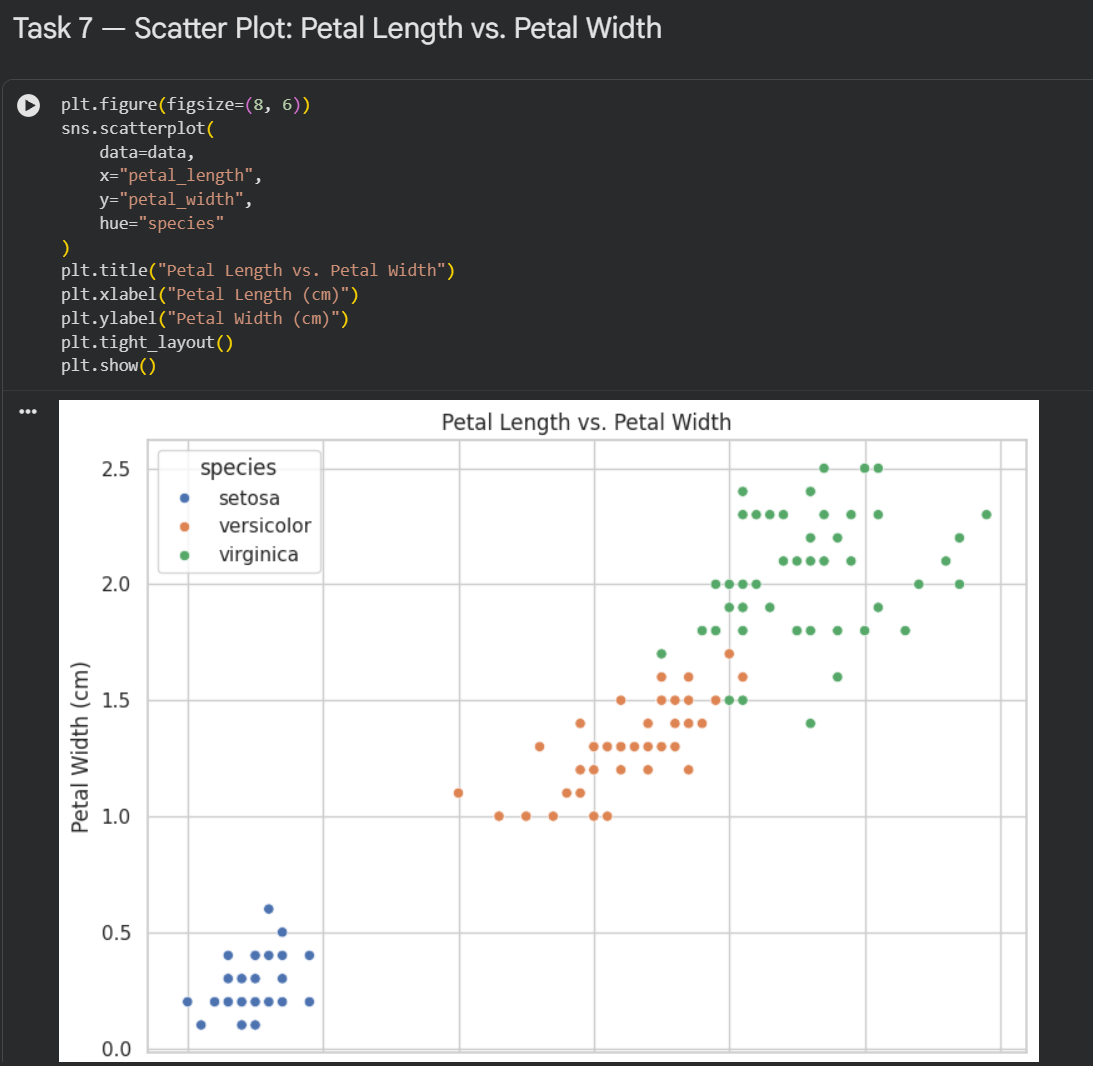

Answer to Task 6

The predicted species should be setosa. This makes sense because the flower’s petal length and width are small, placing it among the compact-petaled Setosa group.

#Task 7 — Experiment With Three New Flowers

Create your own three flowers by choosing different measurements.

Flower 1

Sepal Length:5.0

Sepal Width:3.4

Petal Length:1.5

Petal Width:1.2

Predicted Species:

Flower 2

Sepal Length:6.0

Sepal Width:2.8

Petal Length:4.5

Petal Width:1.3

Predicted Species:

Flower 3

Sepal Length:6.5

Sepal Width:3.0

Petal Length:5.5

Petal Width:2.0



          sepal_length  sepal_width  petal_length  petal_width Predicted Species
Flower 1           5.0          3.4           1.9          1.2            setosa
Flower 2           6.0          2.8           4.5          1.3        versicolor
Flower 3           6.5          3.0           5.5          4.0         virginica


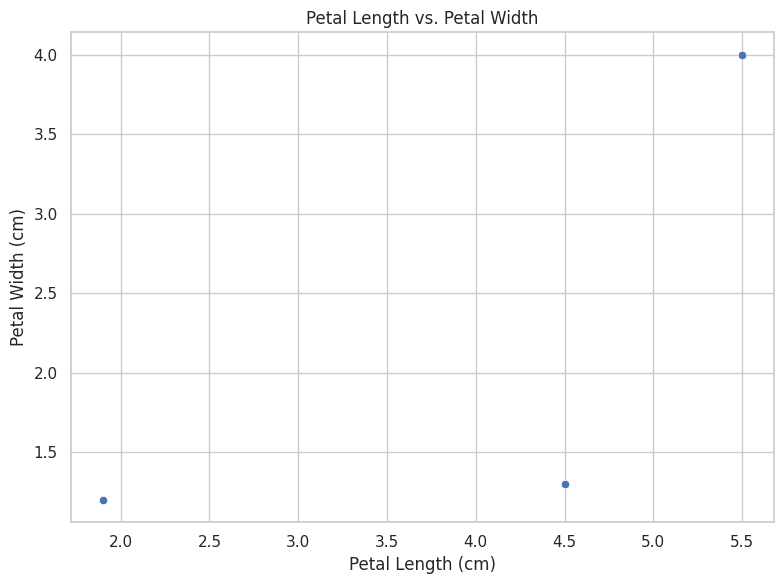

In [68]:

three_flowers = pd.DataFrame(
    [[5.0, 3.4, 1.9, 1.2], [6.0, 2.8, 4.5, 1.3], [6.5, 3.0, 5.5, 4.0]],
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    index=["Flower 1", "Flower 2", "Flower 3"])
three_flowers["Predicted Species"] = model.predict(three_flowers)
print(three_flowers.to_string())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=three_flowers,
    x="petal_length",
    y="petal_width"

)
plt.title("Petal Length vs. Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.tight_layout()
plt.show()


1. Did changing the measurements change the predicted species?
* Yes, moving measurements between the small-, medium-, and large-petal groups changes the predicted species.

2. Which measurements seemed to have the greatest influence based on your experiments?
* Petal length and width seem especially influential because they separate the groups clearly, though sepal measurements can still affect which examples are nearest.

#Task 8 — Experiment With Different Values of K

So far, we used:

n_neighbors=3
Now experiment with:

K = 1
K = 3
K = 5
K = 10

In [69]:
k_values = [1, 3, 5, 10]
accuracies = {}
k_predictions = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    k_predictions[k] = pred
    accuracies[k] = accuracy_score(y_test, pred)
k_results = pd.DataFrame({"K": k_values, "Accuracy": [accuracies[k] for k in k_values]})
print(k_results.to_string(index=False))
print("\nK=3 matches Task 4:", accuracies[3] == accuracy)

 K  Accuracy
 1       1.0
 3       1.0
 5       1.0
10       1.0

K=3 matches Task 4: True


In [70]:
print(k_results.to_string(index=False))
print("\nK=3 matches Task 4:", accuracies[3] == accuracy)

 K  Accuracy
 1       1.0
 3       1.0
 5       1.0
10       1.0

K=3 matches Task 4: True


1. Did changing K change the model accuracy?
* The computed accuracies are in the table above cell

2. Which value produced the highest accuracy?
* Changing K can change accuracy because predictions use a different number of nearby training flowers.
3. Did multiple K values produce the same accuracy?
* A small K follows very local examples; a larger K combines a broader group.
4. Why do you think changing the number of neighbors can influence a prediction?
* The best K here is the value (or tied values) with the highest displayed accuracy; this result only describes this experiment.

#Task 9 — Visualize K vs. Accuracy

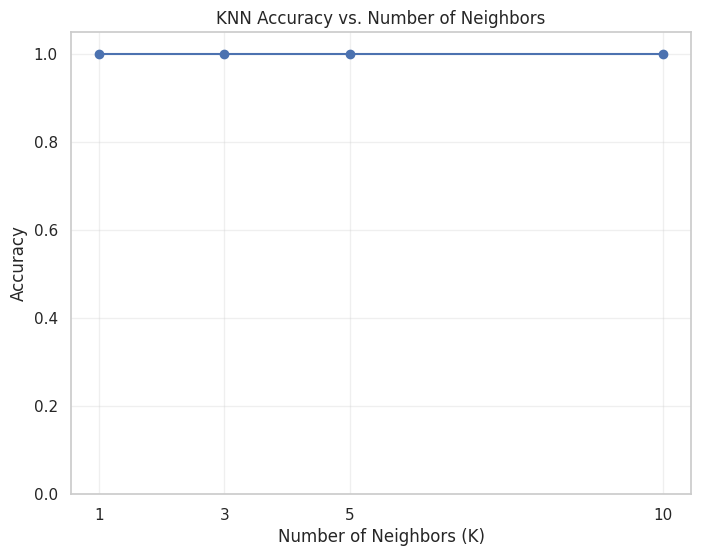

In [71]:
#Create a graph showing:

#Number of Neighbors vs. Model Accuracy

#Create lists containing your experimental values:

k_values = [1, 3, 5, 10]

accuracy_list = [accuracies[k] for k in k_values]

#plot on chart

plt.figure(figsize=(8, 6))
plt.plot(k_values, accuracy_list, marker="o")
plt.xticks(k_values)
plt.ylim(0, 1.05)
plt.title("KNN Accuracy vs. Number of Neighbors")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.show()



1. Which value of K would you choose based on your experiment?
* I would choose a K with the highest accurancy in our experiment we are running here.
2. Why?
* Because one split is just small evidence does't give the grand picture
3. How does the graph make comparing models easier than simply reading numbers?
*  Drawing numbers on graph make easier because graph makes the trend, ties, and drops easier to compare at a glance.

#Task 10 — Connect KNN to Your Assignment 1 Visualization


Return to the Petal Length vs. Petal Width scatter plot from Assignment 1.

Think about how the different species formed groups.

1. How does the scatter plot help explain KNN?
* The scatter plot shows that flowers close in petal length and width often share a species, which is the basic idea behind KNN classifier
2. If a new flower appears close to several Setosa flowers, what would you expect KNN to predict?
* In this case KNN is going to predict that this new flower is also Setosa.
3. What could happen if a new flower appears near the boundary between Versicolor and Virginica?
* In that case we should try to change the K value and try to predict it again. Because if the plot is on the boundary of the two then it can get mixed up.
4. Why might increasing K sometimes make predictions more stable?
* Like in question above sometimes changing K can make the predition decisive when the points are on the boundary of two, And Yes it can make it more stable and accurate by making it less sensitive to one unusal point
5. Why might using a very large K also cause problems?
* I think that big value of L may fall outside the current values and might fall under distant flower grouos which can overwhelm the local pattern.


#Task 11 — Use Fewer Features

In [72]:
#Your original model uses four features:

#Sepal Length
#Sepal Width
#Petal Length
#Petal Width

#Now create another model using only:
#Petal Length
#Petal Width

#Create the new feature set:

X2 = data[
    [
        "petal_length",
        "petal_width"
    ]
]

#Split the data:

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)
#Create the model:

model_2features = KNeighborsClassifier(n_neighbors=3)

#Train:

model_2features.fit(X2_train, y2_train)

#Predict:

predictions_2features = model_2features.predict(X2_test)

#Calculate accuracy:

accuracy_2features = accuracy_score(
    y2_test,
    predictions_2features
)


#lets try to compare
comparison = pd.DataFrame({"Model": ["Four features", "Petal length + petal width"],
                                   "Accuracy": [accuracy, accuracy_2features]})

print(comparison.to_string(index=False))
print("Two-Feature Accuracy:", accuracy_2features)



                     Model  Accuracy
             Four features       1.0
Petal length + petal width       1.0
Two-Feature Accuracy: 1.0


1. Did using only two features increase, decrease, or maintain accuracy?
* No, in our case by using only 2 feature accuracy remained the same. This tells me that models may not need all the features all the time.
2. Do AI models always need every available feature?
* No these may not need all the features and extra features can be noise. As we proved 2 features and 4 features both predicted with same accuracy.
3. Why might petal length and petal width be particularly useful?
* It is because flowers from different species form distinct groups in those measurements as we saw in the plot.
4. How did the visualizations from Assignment 1 help you understand this experiment?
* Scatter plot we created in first assignment made all theis KNNmore sense to understand.

#Task 12 — Think Like an AI Researcher

Answer the following questions in your own words.

Question 1
What is the difference between:
model.fit()
and:
model.predict()
?

* Answer - fit() receives training measurements and known species;
predict() uses what it learned to assign species to new measurements.

Question 2
What is the difference between training data and testing data?

* Training data build the model’s representation which it already know. Testing data estimate how it handles examples it did not train on. Testing data should be separate from train data to make model accurate.

Question 3
What are the features in this AI problem?

* In this problem, we tested first with 4 features ( Sepal length, sepal width, petal length, petal width) and then with 2 features( petal length, petal width)

Question 4
What is the label?

* Flower species: setosa, versicolor, or virginica

Question 5
Why is this a classification problem instead of a regression problem?

* This problem is classification problem, here we are trying to classify flowers into which group they fall. We are not predicting any numbers or future data.

Question 6
Where does KNN obtain the information it uses to predict the species of a new flower?

* It compares new measurements with labeled training flowers and uses the labels of the closest examples.

Question 7
Is KNN the same as manually writing:

if petal_length < 2:
    species = "setosa"
Explain the difference.

* No. These are two different things. A condition is one fixed rule chosen by a person. KNN compares multiple measurements with training examples and predicts from nearby labels.

Question 8
What might happen if many training examples contained incorrect species labels?

* Then the classification will be errored. Because the model will learn the misleading data and produce more errors than accuracy.

Question 9
What might happen if the model were trained using only five flowers?

* The flowers sample size would be less. They may not represent each species’ range, making predictions unreliable and dependent on those few flowers

Question 10
Why do we evaluate an AI model using data it did not use during training?

* The training data is how it learns and if it checks the same already seen data then the genralization may not happen. To avoid that we use separate data.

Question 11
Why can visualization be useful before and after building a machine-learning model?

* Before, plots reveal patterns, groups, and possible data issues. After, they help relate predictions and errors to those patterns.

Question 12
What was the most interesting result you observed in your experiments?

* When we tested with 4 features and then with 2 features the resultant accurancy remained same. This tells me that all features may not always be required for models to classify data accurately. The additional features could may very well be noise to the model.

#Complete AI Workflow

Real-World Data - We start with measurements collected from real flowers.

       ↓

Explore the Data - We inspect rows, columns, and species to understand what was recorded

       ↓

Visualize Patterns - We plot measurements to see how species group or overlap. Like we did in assignment 1

       ↓

Identify Features and Labels - We choose measurements as features and species as the label. In our test we used four features ( Sepal length, sepal width, petal length, petal width) and  the label "setosa"

       ↓

Prepare Training and Testing Data - We divide examples so some train the model and others evaluate it.

       ↓

Choose an Algorithm - We selected KNN, which predicts from nearby labeled examples.

       ↓

Train the Model - used fit() method to train the data with measurements and species

       ↓

Make Predictions - used predict() method to estimate species for measurements

       ↓

Evaluate Accuracy - compare predictions with what we have known

       ↓

Change Model Parameters - change the K factor to see how K size effects results.

       ↓

Compare Results - We compare accuracy and plots across experiments.

       ↓

Improve the Model - We use evidence to choose features and settings, then evaluate again.